# Evaluation Strategies
First, set up our dummy data, and define our model

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_rel



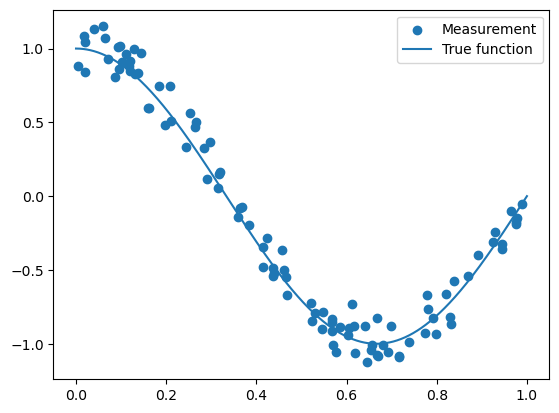

In [26]:
def true_fun(X):
    return np.cos(1.5 * np.pi * X)


np.random.seed(0)

n_samples = 100

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.scatter(X, y, label="Measurement")
plt.plot(np.linspace(0, 1, 1000), true_fun(np.linspace(0, 1, 1000)), label="True function")
plt.legend()

plt.show()

In [27]:

def run_linear_regression(x_train, x_test, y_train, y_test, degree=1):
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(x_train[:, np.newaxis], y_train)

    X_linspace = np.linspace(0, 1, 100)
    y_linspace_true = true_fun(X_linspace)
    y_linspace_model = pipeline.predict(X_linspace[:, np.newaxis])

    y_pred_test = pipeline.predict(x_test[:, np.newaxis])
    y_pred_train = pipeline.predict(x_train[:, np.newaxis])

    plt.plot(X_linspace[:, np.newaxis], y_linspace_model, label="Model function")
    plt.plot(X_linspace[:, np.newaxis], y_linspace_true, label="True function")
    plt.scatter(x_train[:, np.newaxis], y_train, label="Train Measurements")
    plt.scatter(x_test[:, np.newaxis], y_test, label="Test Measurements")
    plt.scatter(x_test[:, np.newaxis], y_pred_test, label="Test Predictions")

    # plt.xlim(-0.01,1.41)
    # plt.ylim(-1.5,2)

    plt.legend()
    plt.show()

    print(f"train MAE = {mean_absolute_error(y_train, y_pred_train):.3f}")
    print(f"test  MAE = {mean_absolute_error(y_test, y_pred_test):.3f}")
    print()
    print(f"train MSE = {mean_squared_error(y_train, y_pred_train):.3f}")
    print(f"test  MSE = {mean_squared_error(y_test, y_pred_test):.3f}")
    print()
    print(f"train  R2 = {r2_score(y_train, y_pred_train):.3f}")
    print(f"test   R2 = {r2_score(y_test, y_pred_test):.3f}")


## Train-test split

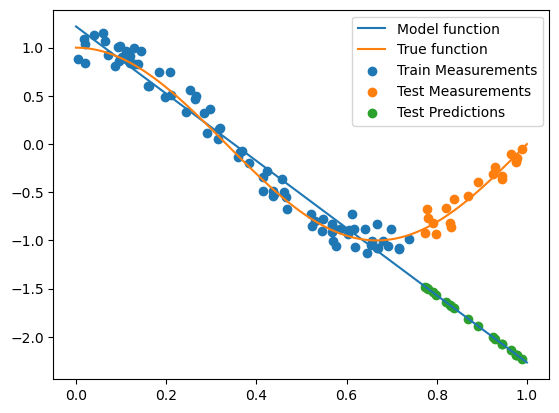

train MAE = 0.129
test  MAE = 1.359

train MSE = 0.024
test  MSE = 2.149

train  R2 = 0.962
test   R2 = -24.501


In [28]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
run_linear_regression(x_train, x_test, y_train, y_test, degree=1)

**Exercise** Do a shuffled train test split

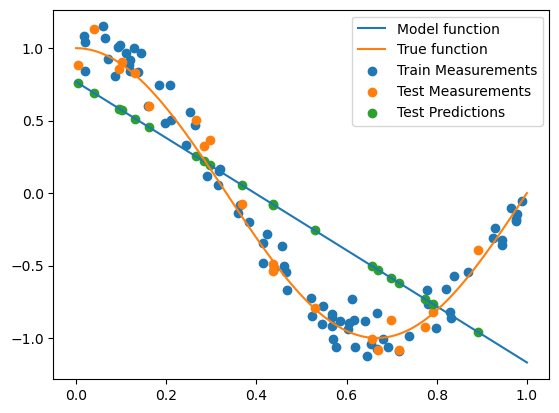

train MAE = 0.406
test  MAE = 0.316

train MSE = 0.225
test  MSE = 0.126

train  R2 = 0.584
test   R2 = 0.790


In [29]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
run_linear_regression(x_train, x_test, y_train, y_test, degree=1)

**Exercise** Find a `degree` that fits the data well.


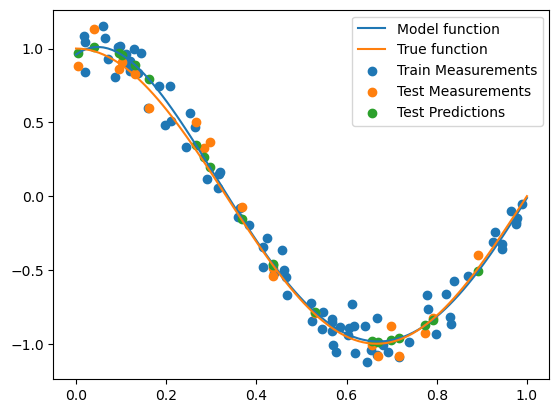

train MAE = 0.084
test  MAE = 0.085

train MSE = 0.010
test  MSE = 0.010

train  R2 = 0.982
test   R2 = 0.984


In [30]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

run_linear_regression(x_train, x_test, y_train, y_test, degree=4)


## k-fold CV

In [31]:

polynomial_features = PolynomialFeatures(degree=1, include_bias=False)
linear_regression = LinearRegression()
pipeline = Pipeline(
    [
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression),
    ]
)

scores = cross_val_score(pipeline, X[:, np.newaxis], y, cv=5, scoring='neg_mean_absolute_error')
print(scores*(-1))

[0.70646744 0.18828263 0.55489856 0.62718248 1.35936292]


**Exercise** Explain why the scores above deviate that much.

**Exercise** Take the code above and randomize the dataset.

In [34]:

polynomial_features = PolynomialFeatures(degree=4, include_bias=False)
linear_regression = LinearRegression()
pipeline = Pipeline(
    [
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression),
    ]
)

np.random.seed(0)
X_shuff, _, y_shuff, _ = train_test_split(X, y, test_size=None, random_state=42, shuffle=True)

scores = cross_val_score(pipeline, X_shuff[:, np.newaxis], y_shuff, cv=5, scoring='neg_mean_absolute_error')
print(scores * (-1))

[0.08690857 0.105675   0.08458403 0.08101419 0.09453236]


**Exercise** (Bonus) Instead of using sklearn's `cross_val_score`, use `cross_validate` and apply all 3 scores at the same time (R2, MAE, MSE)

**Exercise** (Bonus) Instead of using sklearn's `cross_val_score`, use `KFold` to split the dataset into folds and apply your model training and evaluation in a `for` loop.

**Exercise** (Bonus) Student's t-test the results of degree 2 and degree 4 models.

In [36]:
deg2_mae = [0.09931023, 0.11370283, 0.10210184, 0.07881468, 0.10873299]
deg4_mae = [0.08690857, 0.105675, 0.08458403, 0.08101419, 0.09453236]

ttest_rel(deg2_mae, deg4_mae, alternative='greater')

TtestResult(statistic=np.float64(2.928986496865655), pvalue=np.float64(0.021428565599153605), df=np.int64(4))